# Bagging and Random Forests
### Why averaging over randomness beats any single model

I've used both of these professionally — fed data in, got predictions out, moved on. This notebook is about opening the black box: what is actually happening inside a random forest, why it works, and what the numbers mean.

The core idea is counterintuitive: you can take a weak, unstable learner and make it dramatically better by training many copies of it on slightly different data and averaging their predictions. Understanding *why* this works requires understanding the bias-variance decomposition properly — which is where we start.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from collections import Counter

# ── Dark theme ────────────────────────────────────────────────────────────────
BG      = '#0d1117'
SURFACE = '#161b22'
ACCENT  = '#e05c5c'
TEXT    = '#c9d1d9'
MUTED   = '#484f58'
BLUE    = '#58a6ff'
GREEN   = '#3fb950'
YELLOW  = '#d29922'
PURPLE  = '#bc8cff'

rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        MUTED,
    'grid.alpha':        0.3,
    'legend.facecolor':  SURFACE,
    'legend.edgecolor':  MUTED,
    'figure.dpi':        110,
})

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
print("Ready.")

Ready.


## Part 1 — The bias-variance decomposition

Before bagging makes sense, the bias-variance decomposition needs to be precise — not just "small k = high variance" intuition but the actual mathematical statement.

For a regression problem with true function $f(x)$ and noise $\epsilon \sim N(0, \sigma^2)$, the expected squared error of a model $\hat{f}$ at a point $x$ decomposes as:

$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\left(f(x) - \mathbb{E}[\hat{f}(x)]\right)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\left[\left(\hat{f}(x) - \mathbb{E}[\hat{f}(x)]\right)^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

- **Bias²**: how wrong is the model *on average* across different training sets? A model that systematically misses the true function has high bias.
- **Variance**: how much does the model *vary* across different training sets? A model that changes dramatically when the training data changes has high variance.
- **Irreducible noise**: the noise in the data itself. No model can do better than this.

The key insight for bagging: **averaging reduces variance without changing bias**.

If $\hat{f}_1, \hat{f}_2, \ldots, \hat{f}_B$ are independent models each with variance $\sigma^2_{model}$, their average has variance $\sigma^2_{model} / B$. Bias is unchanged because $\mathbb{E}[\frac{1}{B}\sum \hat{f}_b] = \mathbb{E}[\hat{f}]$.

Decision trees have **low bias, high variance** — they can fit any function perfectly (with enough depth) but change dramatically with different training data. They are ideal candidates for variance reduction via averaging.

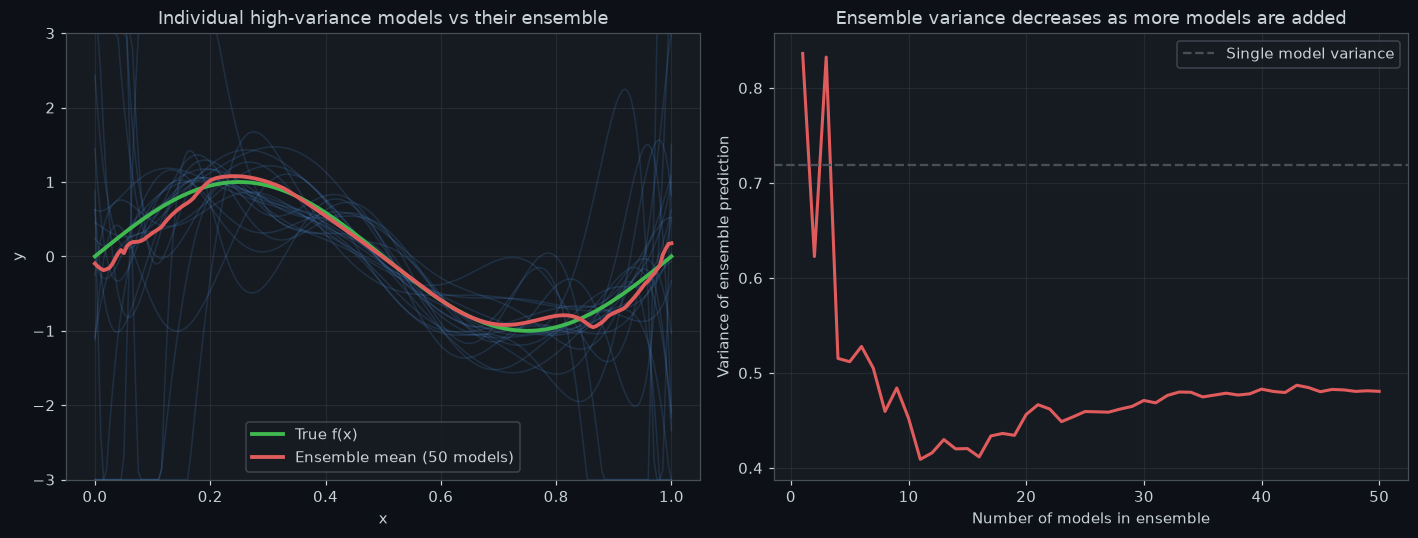

Single model variance (mean over x): 0.7193
Ensemble variance (50 models):         0.4807
Variance reduction:                  1.5x


In [2]:
# ── Demonstrate variance reduction by averaging ────────────────────────────────
# True function: a noisy sine wave
# Simulate many training sets, fit a model to each, measure variance of predictions

def true_f(x):
    return np.sin(2 * np.pi * x)

def make_dataset(n=20, noise=0.3, seed=None):
    rng = np.random.default_rng(seed)
    x = rng.uniform(0, 1, n)
    y = true_f(x) + rng.normal(0, noise, n)
    return x, y

# Fit a high-degree polynomial to each of many training sets
# (polynomials are high-variance learners — like deep decision trees)
x_plot = np.linspace(0, 1, 200)
n_models = 50
degree   = 9

individual_preds = []
for seed in range(n_models):
    x_tr, y_tr = make_dataset(n=20, noise=0.4, seed=seed)
    coeffs = np.polyfit(x_tr, y_tr, degree)
    preds  = np.polyval(coeffs, x_plot)
    # Clip extreme extrapolation for plotting
    preds  = np.clip(preds, -3, 3)
    individual_preds.append(preds)

individual_preds = np.array(individual_preds)   # (n_models, 200)
ensemble_pred    = individual_preds.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i in range(20):
    ax.plot(x_plot, individual_preds[i], color=BLUE, alpha=0.15, linewidth=1)
ax.plot(x_plot, true_f(x_plot), color=GREEN,  linewidth=2.5, label='True f(x)')
ax.plot(x_plot, ensemble_pred,  color=ACCENT,  linewidth=2.5, label=f'Ensemble mean ({n_models} models)')
ax.set_title('Individual high-variance models vs their ensemble', color=TEXT)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_ylim(-3, 3); ax.legend(); ax.grid(True)

ax = axes[1]
pred_variance = individual_preds.var(axis=0)
ensemble_vars = [
    individual_preds[:b].mean(axis=0).var()
    for b in range(1, n_models + 1)
]

ax.plot(range(1, n_models + 1), ensemble_vars, color=ACCENT, linewidth=2)
ax.axhline(pred_variance.mean(), color=MUTED, linestyle='--', label='Single model variance')
ax.set_title('Ensemble variance decreases as more models are added', color=TEXT)
ax.set_xlabel('Number of models in ensemble')
ax.set_ylabel('Variance of ensemble prediction')
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Single model variance (mean over x): {pred_variance.mean():.4f}")
print(f"Ensemble variance ({n_models} models):         {ensemble_vars[-1]:.4f}")
print(f"Variance reduction:                  {pred_variance.mean()/ensemble_vars[-1]:.1f}x")

## Part 2 — Bootstrap sampling

The averaging above assumed we had many independent training sets. In practice we have one. **Bootstrapping** simulates multiple datasets from a single one.

A bootstrap sample is drawn **with replacement** from the training set, the same size as the original. Each bootstrap sample will contain approximately 63.2% of the unique original points (the rest appear multiple times or not at all).

Why 63.2%? The probability that a given point is *not* selected in a single draw is $(1 - 1/n)$. Over $n$ draws:

$$P(\text{point not selected}) = \left(1 - \frac{1}{n}\right)^n \xrightarrow{n \to \infty} e^{-1} \approx 0.368$$

So about 36.8% of points are left out of each bootstrap sample — the **out-of-bag (OOB)** samples. These are genuinely unseen by the model trained on that bootstrap — they can be used as a free validation set.

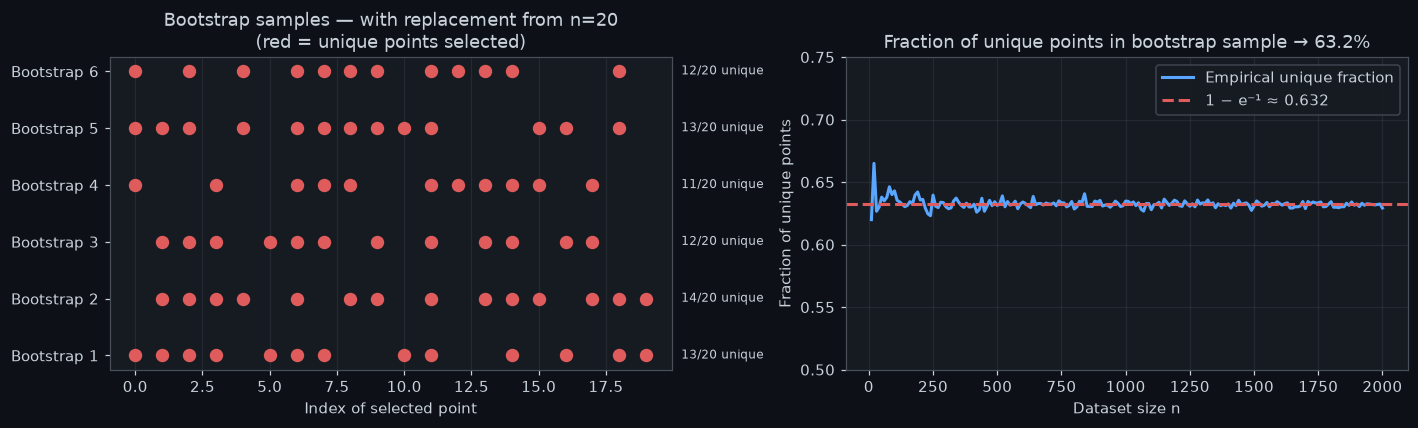

In [3]:
# ── Bootstrap sampling illustrated ────────────────────────────────────────────
n_original = 20
original   = np.arange(n_original)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Show 6 bootstrap samples
ax = axes[0]
unique_fracs = []
for b in range(6):
    boot = np.random.choice(n_original, n_original, replace=True)
    unique = np.unique(boot)
    unique_fracs.append(len(unique) / n_original)
    ax.scatter(boot, np.full(len(boot), b),
               color=BLUE, s=30, alpha=0.6)
    ax.scatter(unique, np.full(len(unique), b),
               color=ACCENT, s=60, zorder=3)
    ax.text(n_original + 0.3, b, f'{len(unique)}/{n_original} unique',
            va='center', fontsize=8, color=TEXT)

ax.set_yticks(range(6))
ax.set_yticklabels([f'Bootstrap {b+1}' for b in range(6)])
ax.set_xlabel('Index of selected point')
ax.set_title('Bootstrap samples — with replacement from n=20\n(red = unique points selected)',
             color=TEXT)
ax.grid(True, axis='x')

# Convergence of unique fraction to 63.2%
ax = axes[1]
ns = np.arange(10, 2001, 10)
fracs = []
for n in ns:
    trials = [len(np.unique(np.random.choice(n, n, replace=True)))/n
              for _ in range(20)]
    fracs.append(np.mean(trials))

ax.plot(ns, fracs, color=BLUE, linewidth=2, label='Empirical unique fraction')
ax.axhline(1 - np.exp(-1), color=ACCENT, linestyle='--', linewidth=2,
           label=f'1 − e⁻¹ ≈ {1-np.exp(-1):.3f}')
ax.set_title('Fraction of unique points in bootstrap sample → 63.2%', color=TEXT)
ax.set_xlabel('Dataset size n')
ax.set_ylabel('Fraction of unique points')
ax.set_ylim(0.5, 0.75)
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

## Part 3 — Decision trees: the base learner

Bagging needs a base learner to aggregate. The standard choice is a **decision tree** — and understanding why requires knowing what makes a tree split.

A decision tree recursively partitions the feature space by choosing splits that maximise the **purity** of the resulting subsets. For classification, the standard purity measure is the **Gini impurity**:

$$G = 1 - \sum_{k=1}^{K} p_k^2$$

Where $p_k$ is the proportion of class $k$ in the node. $G = 0$ means all samples belong to one class (perfectly pure). $G$ is maximised when all classes are equally represented.

At each node, the tree searches over all features and all possible split thresholds, choosing the split that gives the largest **weighted reduction in Gini impurity**:

$$\Delta G = G_{parent} - \frac{n_L}{n}G_L - \frac{n_R}{n}G_R$$

This is the **information gain** (Gini version). The tree keeps splitting until nodes are pure or a stopping criterion is met (max depth, minimum samples per leaf, etc.).

In [4]:
# ── Decision tree from scratch ────────────────────────────────────────────────

def gini(y):
    """Gini impurity of a set of labels."""
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs  = counts / len(y)
    return 1.0 - np.sum(probs**2)

def best_split(X, y, n_features_subset=None):
    """
    Find the best (feature, threshold) split by minimising weighted Gini.
    n_features_subset: if set, only consider a random subset of features
                       (this is the Random Forest modification).
    """
    n, d     = X.shape
    features = np.arange(d)
    if n_features_subset is not None:
        features = np.random.choice(d, n_features_subset, replace=False)

    best_gain  = -np.inf
    best_feat  = None
    best_thresh = None

    g_parent = gini(y)

    for feat in features:
        thresholds = np.unique(X[:, feat])
        for thresh in thresholds:
            left  = y[X[:, feat] <= thresh]
            right = y[X[:, feat] >  thresh]
            if len(left) == 0 or len(right) == 0:
                continue
            gain = g_parent - (len(left)/n * gini(left) +
                               len(right)/n * gini(right))
            if gain > best_gain:
                best_gain  = gain
                best_feat  = feat
                best_thresh = thresh

    return best_feat, best_thresh, best_gain


class DecisionTree:
    """Recursive decision tree for classification."""
    def __init__(self, max_depth=None, min_samples=2, n_features_subset=None):
        self.max_depth         = max_depth
        self.min_samples       = min_samples
        self.n_features_subset = n_features_subset  # None = use all (plain tree)

    def fit(self, X, y, depth=0):
        self.n_classes = len(np.unique(y))
        self._grow(X, y, depth)
        return self

    def _grow(self, X, y, depth):
        # Leaf conditions
        if (len(y) < self.min_samples or
            gini(y) == 0 or
            (self.max_depth is not None and depth >= self.max_depth)):
            self.is_leaf    = True
            self.prediction = Counter(y).most_common(1)[0][0]
            self.proba      = np.bincount(y, minlength=3) / len(y)
            return

        feat, thresh, gain = best_split(X, y, self.n_features_subset)

        if feat is None or gain <= 0:
            self.is_leaf    = True
            self.prediction = Counter(y).most_common(1)[0][0]
            self.proba      = np.bincount(y, minlength=3) / len(y)
            return

        self.is_leaf = False
        self.feat    = feat
        self.thresh  = thresh

        left_mask  = X[:, feat] <= thresh
        right_mask = ~left_mask

        self.left  = DecisionTree(self.max_depth, self.min_samples, self.n_features_subset)
        self.right = DecisionTree(self.max_depth, self.min_samples, self.n_features_subset)
        self.left._grow(X[left_mask],  y[left_mask],  depth + 1)
        self.right._grow(X[right_mask], y[right_mask], depth + 1)

    def predict_one(self, x):
        if self.is_leaf:
            return self.prediction
        if x[self.feat] <= self.thresh:
            return self.left.predict_one(x)
        return self.right.predict_one(x)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])


print("Decision tree defined.")
print(f"Gini impurity examples:")
print(f"  All same class [0,0,0,0]:     {gini(np.array([0,0,0,0])):.4f}  (pure)")
print(f"  50/50 split [0,0,1,1]:        {gini(np.array([0,0,1,1])):.4f}  (maximum for 2 classes)")
print(f"  75/25 split [0,0,0,1]:        {gini(np.array([0,0,0,1])):.4f}")

Decision tree defined.
Gini impurity examples:
  All same class [0,0,0,0]:     0.0000  (pure)
  50/50 split [0,0,1,1]:        0.5000  (maximum for 2 classes)
  75/25 split [0,0,0,1]:        0.3750


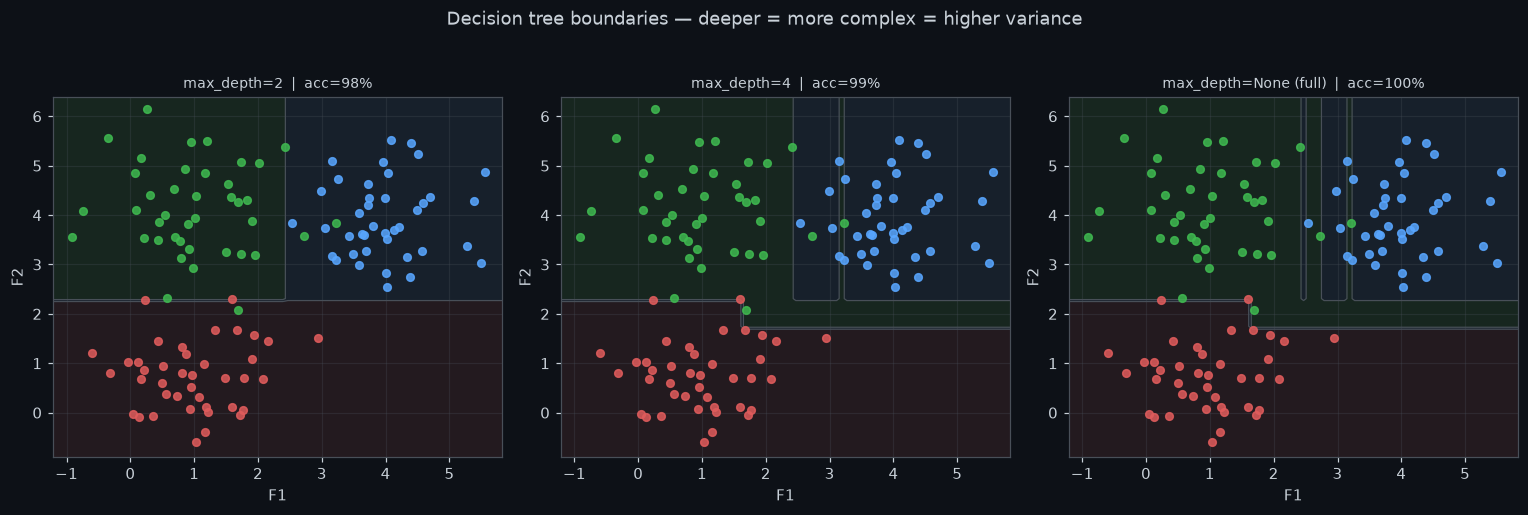

In [5]:
# ── Fit a decision tree and visualise ─────────────────────────────────────────
from matplotlib.colors import ListedColormap

rng = np.random.default_rng(5)
centres = [[1,1], [4,4], [1,4]]
X_cls = np.vstack([rng.normal(c, 0.8, (40,2)) for c in centres])
y_cls = np.array([0]*40 + [1]*40 + [2]*40)

def plot_tree_boundary(ax, tree, X, y, title, res=0.08):
    x0_min, x0_max = X[:,0].min()-0.3, X[:,0].max()+0.3
    x1_min, x1_max = X[:,1].min()-0.3, X[:,1].max()+0.3
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, res),
                         np.arange(x1_min, x1_max, res))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cmap_bg = ListedColormap(['#3d1a1a', '#1a2a3d', '#1a3d1a'])
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg, levels=[-0.5,0.5,1.5,2.5])
    ax.contour(xx, yy, Z, colors=[MUTED], linewidths=0.8, levels=[0.5,1.5])
    for cls, col in enumerate([ACCENT, BLUE, GREEN]):
        m = y==cls
        ax.scatter(X[m,0], X[m,1], color=col, s=25, alpha=0.85, zorder=3)
    acc = (tree.predict(X) == y).mean()
    ax.set_title(f'{title}  |  acc={acc:.0%}', color=TEXT, fontsize=9)
    ax.set_xlabel('F1'); ax.set_ylabel('F2'); ax.grid(True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, depth in zip(axes, [2, 4, None]):
    t = DecisionTree(max_depth=depth).fit(X_cls, y_cls)
    label = f'max_depth={depth}' if depth else 'max_depth=None (full)'
    plot_tree_boundary(ax, t, X_cls, y_cls, label)

fig.suptitle('Decision tree boundaries — deeper = more complex = higher variance',
             color=TEXT, y=1.03)
plt.tight_layout()
plt.show()

## Part 4 — Bagging: Bootstrap AGGregating

Leo Breiman (1994) proposed bagging: train $B$ trees on $B$ different bootstrap samples of the training data, then average their predictions.

**For regression**: average the predictions  
**For classification**: majority vote across trees

Each tree sees a different bootstrap sample — so each tree is different. Trees that happen to catch the same noisy points will make similar errors, but the errors will be somewhat uncorrelated across trees. Averaging uncorrelated errors reduces variance.

The crucial observation: the more **correlated** the trees are, the less variance reduction you get. If all trees make the same errors, averaging does nothing. This is what Random Forests fix.

In [6]:
class BaggedTrees:
    """
    Bagging: B decision trees, each trained on a bootstrap sample.
    n_features_subset: passed to each tree (None = bagging, int = random forest)
    """
    def __init__(self, n_trees=50, max_depth=None, n_features_subset=None, seed=0):
        self.n_trees            = n_trees
        self.max_depth          = max_depth
        self.n_features_subset  = n_features_subset
        self.seed               = seed

    def fit(self, X, y):
        np.random.seed(self.seed)
        n = len(y)
        self.trees   = []
        self.oob_idx = []

        for b in range(self.n_trees):
            # Bootstrap sample
            boot_idx = np.random.choice(n, n, replace=True)
            oob_mask = np.ones(n, dtype=bool)
            oob_mask[np.unique(boot_idx)] = False
            self.oob_idx.append(np.where(oob_mask)[0])

            tree = DecisionTree(max_depth=self.max_depth,
                                n_features_subset=self.n_features_subset)
            tree.fit(X[boot_idx], y[boot_idx])
            self.trees.append(tree)

        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X):
        """Majority vote across all trees."""
        all_preds = np.array([t.predict(X) for t in self.trees])  # (n_trees, n)
        # Majority vote per sample
        return np.array([Counter(all_preds[:, i]).most_common(1)[0][0]
                         for i in range(X.shape[0])])

    def predict_proba(self, X, n_classes=3):
        """Fraction of trees voting for each class."""
        all_preds = np.array([t.predict(X) for t in self.trees])
        proba = np.zeros((X.shape[0], n_classes))
        for i in range(X.shape[0]):
            counts = Counter(all_preds[:, i])
            for cls, cnt in counts.items():
                if cls < n_classes:
                    proba[i, cls] = cnt / self.n_trees
        return proba

    def oob_score(self):
        """
        Out-of-bag score: for each training point, average predictions
        from only the trees that did NOT see it during training.
        """
        n = len(self.y_train)
        oob_preds = np.full(n, -1)

        for i in range(n):
            # Trees that did not see point i
            trees_for_i = [t for t, oob in zip(self.trees, self.oob_idx)
                           if i in oob]
            if len(trees_for_i) == 0:
                continue
            votes = [t.predict_one(self.X_train[i]) for t in trees_for_i]
            oob_preds[i] = Counter(votes).most_common(1)[0][0]

        valid = oob_preds >= 0
        return (oob_preds[valid] == self.y_train[valid]).mean()


# Train and evaluate
rng2 = np.random.default_rng(10)
idx  = np.random.permutation(len(y_cls))
split = int(0.7 * len(y_cls))
X_tr, y_tr = X_cls[idx[:split]], y_cls[idx[:split]]
X_te, y_te = X_cls[idx[split:]], y_cls[idx[split:]]

single_tree = DecisionTree(max_depth=None).fit(X_tr, y_tr)
bagged      = BaggedTrees(n_trees=50, max_depth=None).fit(X_tr, y_tr)

single_test_acc = (single_tree.predict(X_te) == y_te).mean()
bagged_test_acc = (bagged.predict(X_te) == y_te).mean()
oob_acc         = bagged.oob_score()

print(f"Single full tree — test accuracy:  {single_test_acc:.1%}")
print(f"Bagged (50 trees) — test accuracy: {bagged_test_acc:.1%}")
print(f"Bagged (50 trees) — OOB accuracy:  {oob_acc:.1%}  (free validation estimate)")

Single full tree — test accuracy:  94.4%
Bagged (50 trees) — test accuracy: 94.4%
Bagged (50 trees) — OOB accuracy:  94.0%  (free validation estimate)


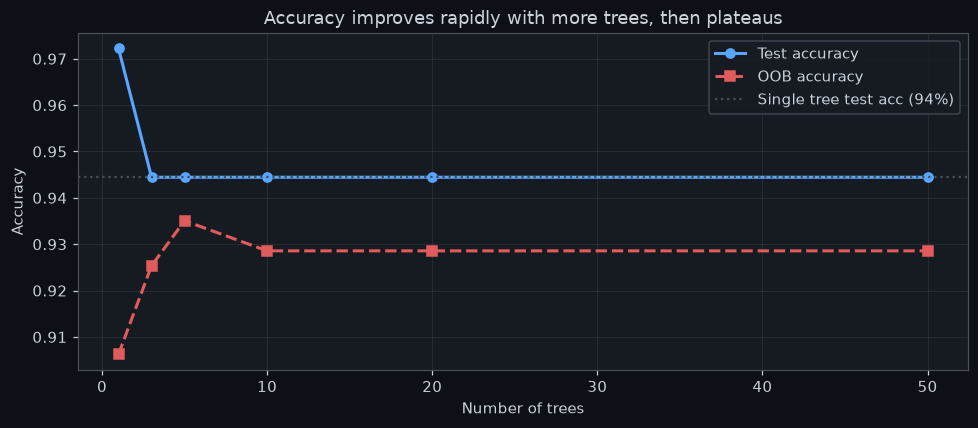

OOB accuracy tracks test accuracy closely — a useful free validation estimate.
The improvement plateaus: adding trees beyond ~20-50 rarely helps much.


In [7]:
# ── How accuracy improves with number of trees ─────────────────────────────────
tree_counts = [1, 3, 5, 10, 20, 50]
test_accs, oob_accs = [], []

for n_t in tree_counts:
    b = BaggedTrees(n_trees=n_t, max_depth=None, seed=42).fit(X_tr, y_tr)
    test_accs.append((b.predict(X_te) == y_te).mean())
    oob_accs.append(b.oob_score())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tree_counts, test_accs, color=BLUE,   marker='o', linewidth=2, label='Test accuracy')
ax.plot(tree_counts, oob_accs,  color=ACCENT, marker='s', linewidth=2,
        linestyle='--', label='OOB accuracy')
ax.axhline(single_test_acc, color=MUTED, linestyle=':', linewidth=1.5,
           label=f'Single tree test acc ({single_test_acc:.0%})')
ax.set_title('Accuracy improves rapidly with more trees, then plateaus', color=TEXT)
ax.set_xlabel('Number of trees')
ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

print("OOB accuracy tracks test accuracy closely — a useful free validation estimate.")
print("The improvement plateaus: adding trees beyond ~20-50 rarely helps much.")

## Part 5 — Random Forests: decorrelating the trees

Breiman (2001) made one modification to bagging that turned it into Random Forests: at each split, instead of searching over all features, **randomly sample $m$ features** and only consider those.

The standard recommendation is $m = \lfloor\sqrt{d}\rfloor$ for classification and $m = \lfloor d/3 \rfloor$ for regression, where $d$ is the total number of features.

Why does this help? Consider a dataset with one very strong predictor. In bagging, nearly every tree will split on that predictor first — making the trees highly correlated. Correlated errors don't cancel when you average. By randomly excluding features at each split, weaker predictors get a chance to be the best available option, and the trees become more diverse.

The variance of an average of $B$ trees with pairwise correlation $\rho$ and individual variance $\sigma^2$ is:

$$\text{Var}\left(\frac{1}{B}\sum_b \hat{f}_b\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As $B \to \infty$, this converges to $\rho\sigma^2$ — not zero. The correlation between trees is a hard floor on variance reduction. Random feature sampling reduces $\rho$, lowering that floor.

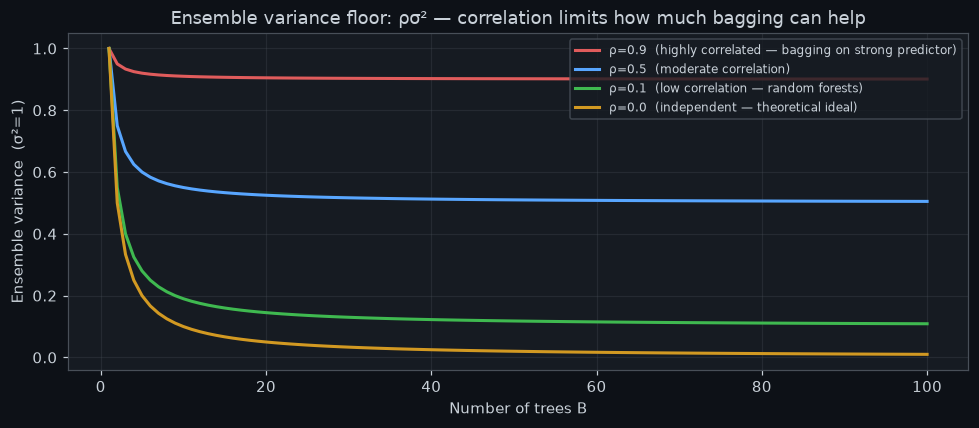

If ρ=0.9: even with 100 trees, ensemble variance is still 0.9σ² — barely reduced.
If ρ=0.1: with 20 trees, variance is ~0.145σ² — a 7x reduction.

Random feature sampling reduces ρ. That's the Random Forest insight.


In [8]:
# ── Variance floor from tree correlation ──────────────────────────────────────
sigma2 = 1.0  # individual tree variance
B_vals = np.arange(1, 101)

fig, ax = plt.subplots(figsize=(9, 4))

for rho, col, label in [
    (0.9,  ACCENT, 'ρ=0.9  (highly correlated — bagging on strong predictor)'),
    (0.5,  BLUE,   'ρ=0.5  (moderate correlation)'),
    (0.1,  GREEN,  'ρ=0.1  (low correlation — random forests)'),
    (0.0,  YELLOW, 'ρ=0.0  (independent — theoretical ideal)'),
]:
    var_ensemble = rho * sigma2 + (1 - rho) * sigma2 / B_vals
    ax.plot(B_vals, var_ensemble, color=col, linewidth=2, label=label)

ax.set_title('Ensemble variance floor: ρσ² — correlation limits how much bagging can help',
             color=TEXT)
ax.set_xlabel('Number of trees B')
ax.set_ylabel('Ensemble variance  (σ²=1)')
ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout()
plt.show()

print("If ρ=0.9: even with 100 trees, ensemble variance is still 0.9σ² — barely reduced.")
print("If ρ=0.1: with 20 trees, variance is ~0.145σ² — a 7x reduction.")
print("\nRandom feature sampling reduces ρ. That's the Random Forest insight.")

Features per split (m_try = √d): 1 of 2

Method                  Test acc     OOB acc
────────────────────────────────────────────
Single tree                94.4%           —
Bagging (all feat)         94.4%       94.0%
Random Forest (√d)         94.4%       95.2%


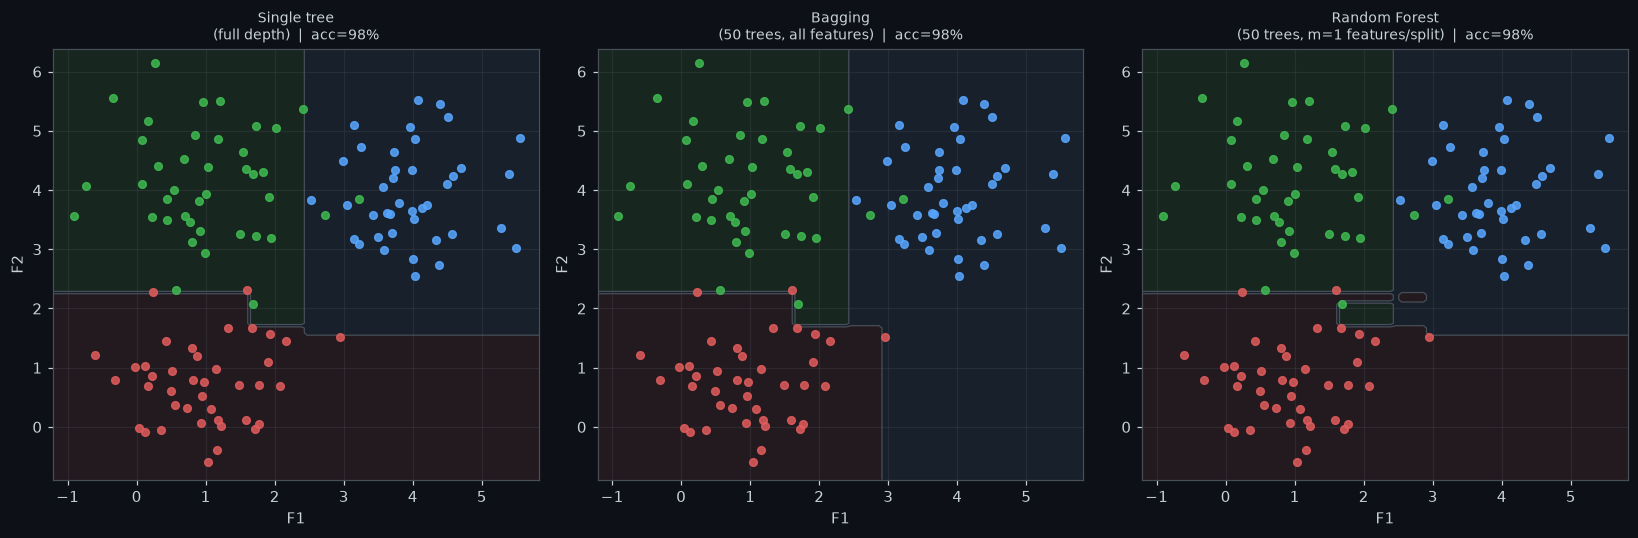

In [9]:
# ── Compare bagging vs random forest ──────────────────────────────────────────
n_features = X_tr.shape[1]
m_try      = max(1, int(np.sqrt(n_features)))  # √d features per split

rf = BaggedTrees(n_trees=50, max_depth=None,
                 n_features_subset=m_try, seed=42).fit(X_tr, y_tr)

rf_test_acc = (rf.predict(X_te) == y_te).mean()
rf_oob_acc  = rf.oob_score()

print(f"Features per split (m_try = √d): {m_try} of {n_features}")
print()
print(f"{'Method':20s}  {'Test acc':>10s}  {'OOB acc':>10s}")
print("─" * 44)
print(f"{'Single tree':20s}  {single_test_acc:>10.1%}  {'—':>10s}")
print(f"{'Bagging (all feat)':20s}  {bagged_test_acc:>10.1%}  {oob_acc:>10.1%}")
print(f"{'Random Forest (√d)':20s}  {rf_test_acc:>10.1%}  {rf_oob_acc:>10.1%}")

# Decision boundary comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, model, title in zip(axes,
    [single_tree, bagged, rf],
    ['Single tree\n(full depth)',
     'Bagging\n(50 trees, all features)',
     f'Random Forest\n(50 trees, m={m_try} features/split)']):
    plot_tree_boundary(ax, model, X_cls, y_cls, title)

plt.tight_layout()
plt.show()

## Part 6 — Feature importance

One of the most useful outputs of a random forest is a measure of **feature importance** — which features actually mattered for the predictions.

The standard measure is **mean decrease in impurity (MDI)**: for each feature, sum the Gini impurity reduction at every split that used that feature, weighted by the number of samples at that node, averaged across all trees.

$$\text{Importance}(f) = \frac{1}{B}\sum_{b=1}^{B} \sum_{t \in \text{nodes using } f} \frac{n_t}{n} \cdot \Delta G_t$$

Features that are used frequently at high nodes (early splits, many samples flowing through) get high importance. Features used only in deep, low-sample nodes get low importance.

**Caveat**: MDI has a known bias toward high-cardinality features (features with many unique values offer more potential splits). The **permutation importance** method avoids this by measuring how much test accuracy drops when a feature's values are randomly shuffled — but it's more expensive to compute.

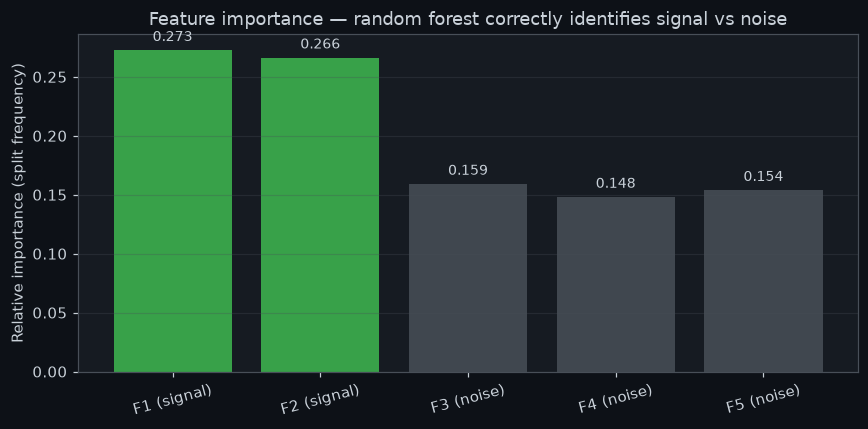

Random forest accuracy: 100.0%

F1 + F2 importance: 53.9% of total
F3 + F4 + F5 importance: 46.1% of total

The forest correctly identifies that only the first two features matter.


In [10]:
# ── Feature importance on a dataset where we know the answer ──────────────────
# Build a dataset with 2 informative features and 3 pure noise features

rng3 = np.random.default_rng(20)
n_samples = 200

# Informative features
f1 = rng3.normal(0, 1, n_samples)
f2 = rng3.normal(0, 1, n_samples)

# Pure noise features
noise = rng3.normal(0, 1, (n_samples, 3))

X_imp = np.column_stack([f1, f2, noise])
y_imp = ((f1 + f2) > 0).astype(int)   # labels determined only by f1 + f2

feature_names = ['F1 (signal)', 'F2 (signal)', 'F3 (noise)', 'F4 (noise)', 'F5 (noise)']

def compute_feature_importance(trees, n_features):
    """
    Accumulate Gini-based feature importance across all trees.
    We track importance during tree building by annotating each node.
    Here we approximate by counting split frequencies per feature.
    """
    importance = np.zeros(n_features)

    def traverse(node, n_total):
        if node.is_leaf:
            return
        importance[node.feat] += 1
        traverse(node.left, n_total)
        traverse(node.right, n_total)

    for tree in trees:
        traverse(tree, len(y_imp))

    importance /= importance.sum()
    return importance


rf_imp = BaggedTrees(n_trees=100, max_depth=None,
                     n_features_subset=2, seed=1).fit(X_imp, y_imp)

importances = compute_feature_importance(rf_imp.trees, n_features=5)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [GREEN, GREEN, MUTED, MUTED, MUTED]
bars = ax.bar(feature_names, importances, color=colors, alpha=0.85)
ax.set_title('Feature importance — random forest correctly identifies signal vs noise',
             color=TEXT)
ax.set_ylabel('Relative importance (split frequency)')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y')
for bar, imp in zip(bars, importances):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{imp:.3f}', ha='center', va='bottom', fontsize=9, color=TEXT)
plt.tight_layout()
plt.show()

acc_imp = (rf_imp.predict(X_imp) == y_imp).mean()
print(f"Random forest accuracy: {acc_imp:.1%}")
print(f"\nF1 + F2 importance: {importances[:2].sum():.1%} of total")
print(f"F3 + F4 + F5 importance: {importances[2:].sum():.1%} of total")
print("\nThe forest correctly identifies that only the first two features matter.")

## Part 7 — Permutation importance: the more honest version

MDI importance has a problem: it's computed on training data, so features that happen to correlate with the target on the training set look important even if they're noise.

**Permutation importance** measures the actual impact of a feature on held-out performance:

1. Evaluate the model on a test set → baseline accuracy
2. For each feature $j$: randomly shuffle its values in the test set (breaking any relationship with the target) → measure accuracy drop
3. Importance = baseline accuracy − shuffled accuracy

Features with high permutation importance are genuinely doing work. Features with near-zero permutation importance aren't — even if MDI says otherwise.

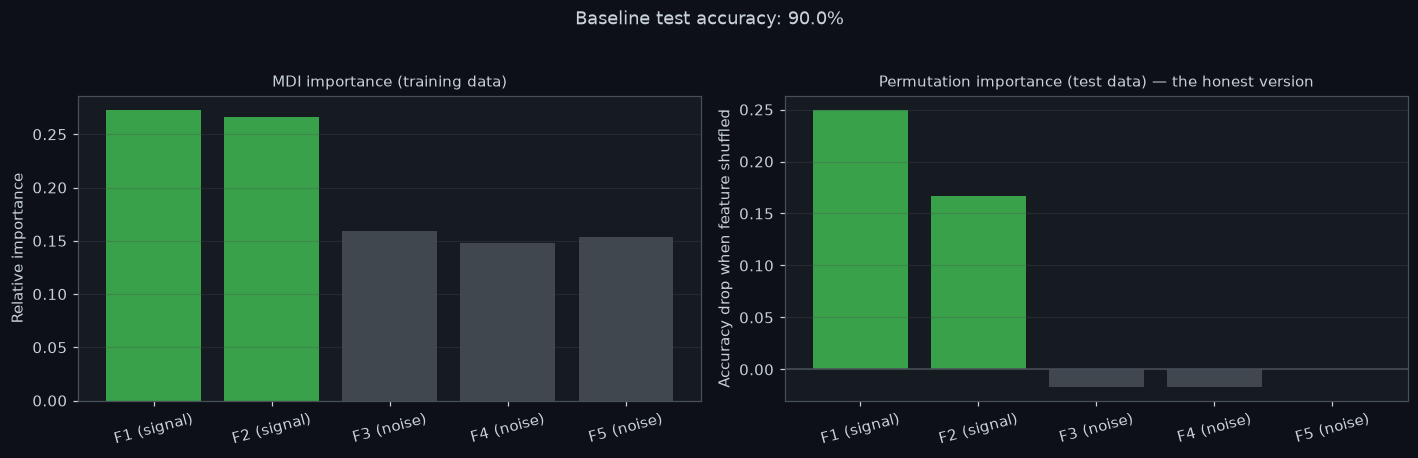

Permutation importance confirms: only F1 and F2 matter.
Shuffling noise features causes no accuracy drop — as expected.


In [11]:
# ── Permutation importance ─────────────────────────────────────────────────────
idx_imp = np.random.permutation(n_samples)
sp_imp  = int(0.7 * n_samples)
X_tr_i, y_tr_i = X_imp[idx_imp[:sp_imp]], y_imp[idx_imp[:sp_imp]]
X_te_i, y_te_i = X_imp[idx_imp[sp_imp:]], y_imp[idx_imp[sp_imp:]]

rf_perm = BaggedTrees(n_trees=100, max_depth=None,
                      n_features_subset=2, seed=2).fit(X_tr_i, y_tr_i)

baseline_acc = (rf_perm.predict(X_te_i) == y_te_i).mean()

perm_importances = []
for feat in range(X_te_i.shape[1]):
    X_permuted = X_te_i.copy()
    X_permuted[:, feat] = np.random.permutation(X_permuted[:, feat])
    acc_permuted = (rf_perm.predict(X_permuted) == y_te_i).mean()
    perm_importances.append(baseline_acc - acc_permuted)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(feature_names, importances, color=colors, alpha=0.85)
ax.set_title('MDI importance (training data)', color=TEXT, fontsize=10)
ax.set_ylabel('Relative importance')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y')

ax = axes[1]
perm_colors = [GREEN if p > 0.01 else MUTED for p in perm_importances]
ax.bar(feature_names, perm_importances, color=perm_colors, alpha=0.85)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_title('Permutation importance (test data) — the honest version', color=TEXT, fontsize=10)
ax.set_ylabel('Accuracy drop when feature shuffled')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y')

fig.suptitle(f'Baseline test accuracy: {baseline_acc:.1%}', color=TEXT, y=1.03)
plt.tight_layout()
plt.show()

print("Permutation importance confirms: only F1 and F2 matter.")
print("Shuffling noise features causes no accuracy drop — as expected.")

## Part 8 — What random forests can and can't do

After years of using them as black boxes, the things I now understand that I didn't before:

**What they're genuinely good at:**
- Tabular data, especially mixed types (categorical and continuous together)
- Handling missing values and outliers gracefully
- Requiring minimal preprocessing — no scaling needed (trees are scale-invariant)
- Feature importance as a diagnostic tool — tells you which features to keep or investigate
- OOB score as a free validation estimate — no separate validation set needed
- Resistant to overfitting as you add more trees (adding trees never hurts, it just plateaus)

**What they can't do:**
- Extrapolate beyond the range of the training data. Trees predict the mean of a leaf's training samples. The maximum prediction is bounded by the maximum training label. For regression tasks where test data may exceed the training range, this is a serious limitation.
- Model smooth functions efficiently. A decision tree approximates smooth functions with step functions — you need many trees and deep trees to approximate something like a sine wave well.
- Compete with deep learning on images, text, or sequences. Inductive biases (convolution, attention) built into neural architectures encode domain knowledge that trees can't access.

**When random forests still win in practice**: structured/tabular data competitions, interpretability requirements, limited data (deep learning needs more), fast iteration (random forests train in seconds; neural networks in hours).

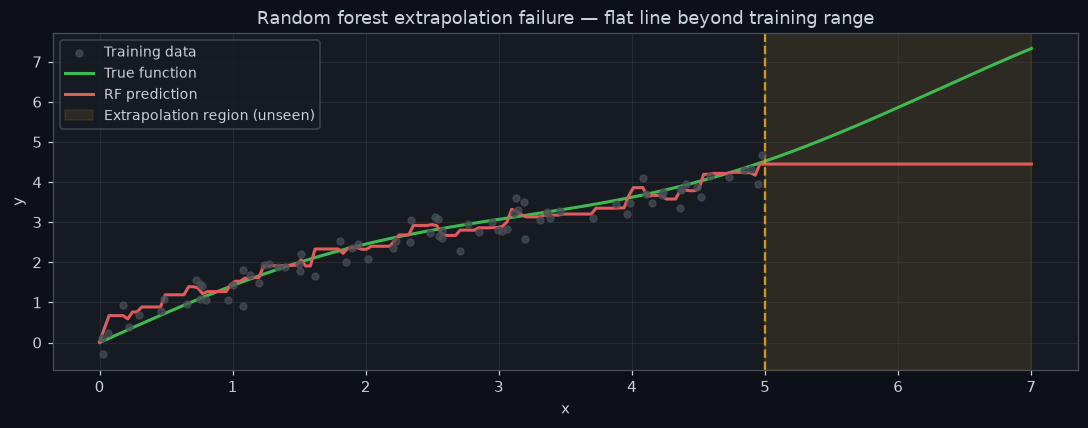

In the training range (0-5): RF tracks the function well.
In the extrapolation range (5-7): RF predicts a flat line —
the maximum training target value. Trees cannot extrapolate.


In [12]:
# ── Demonstrate extrapolation failure ─────────────────────────────────────────
rng4 = np.random.default_rng(7)
x_reg_tr = rng4.uniform(0, 5, 80).reshape(-1, 1)
y_reg_tr  = x_reg_tr.ravel() + 0.5 * np.sin(x_reg_tr.ravel()) + rng4.normal(0, 0.3, 80)

# Test includes extrapolation region (5-7)
x_reg_te = np.linspace(0, 7, 200).reshape(-1, 1)
y_reg_te  = x_reg_te.ravel() + 0.5 * np.sin(x_reg_te.ravel())

# Simple regression forest: predict mean of leaf
class RegressionTree:
    def __init__(self, max_depth=None, min_samples=5, n_features_subset=None):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.n_features_subset = n_features_subset

    def fit(self, X, y, depth=0):
        self._grow(X, y, depth)
        return self

    def _grow(self, X, y, depth):
        if (len(y) < self.min_samples or
           (self.max_depth is not None and depth >= self.max_depth)):
            self.is_leaf    = True
            self.prediction = y.mean()
            return

        n, d  = X.shape
        feats = np.arange(d)
        if self.n_features_subset:
            feats = np.random.choice(d, self.n_features_subset, replace=False)

        best_mse, best_feat, best_thresh = np.inf, None, None
        for feat in feats:
            for thresh in np.unique(X[:, feat]):
                l = y[X[:, feat] <= thresh]
                r = y[X[:, feat] >  thresh]
                if len(l) == 0 or len(r) == 0:
                    continue
                mse = len(l)*l.var() + len(r)*r.var()
                if mse < best_mse:
                    best_mse, best_feat, best_thresh = mse, feat, thresh

        if best_feat is None:
            self.is_leaf    = True
            self.prediction = y.mean()
            return

        self.is_leaf = False
        self.feat    = best_feat
        self.thresh  = best_thresh
        lm = X[:, best_feat] <= best_thresh
        self.left  = RegressionTree(self.max_depth, self.min_samples, self.n_features_subset)
        self.right = RegressionTree(self.max_depth, self.min_samples, self.n_features_subset)
        self.left._grow(X[lm], y[lm], depth+1)
        self.right._grow(X[~lm], y[~lm], depth+1)

    def predict_one(self, x):
        if self.is_leaf:
            return self.prediction
        return (self.left if x[self.feat] <= self.thresh else self.right).predict_one(x)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

# Train regression forest
rf_reg_preds = []
for b in range(50):
    boot = np.random.choice(len(y_reg_tr), len(y_reg_tr), replace=True)
    t = RegressionTree(max_depth=5).fit(x_reg_tr[boot], y_reg_tr[boot])
    rf_reg_preds.append(t.predict(x_reg_te))
rf_reg_pred = np.mean(rf_reg_preds, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x_reg_tr, y_reg_tr, color=MUTED, s=20, alpha=0.7, label='Training data', zorder=3)
ax.plot(x_reg_te, y_reg_te,    color=GREEN,  linewidth=2, label='True function')
ax.plot(x_reg_te, rf_reg_pred, color=ACCENT, linewidth=2, label='RF prediction')
ax.axvspan(5, 7, alpha=0.12, color=YELLOW, label='Extrapolation region (unseen)')
ax.axvline(5, color=YELLOW, linewidth=1.5, linestyle='--')
ax.set_title('Random forest extrapolation failure — flat line beyond training range', color=TEXT)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9); ax.grid(True)
plt.tight_layout()
plt.show()

print("In the training range (0-5): RF tracks the function well.")
print("In the extrapolation range (5-7): RF predicts a flat line —")
print("the maximum training target value. Trees cannot extrapolate.")

## Summary

| Concept | What it is |
|---------|------------|
| **Bias-variance decomposition** | Error = Bias² + Variance + Irreducible noise |
| **Averaging reduces variance** | $\text{Var}(\bar{f}) = \sigma^2/B$ for independent models |
| **Bootstrap** | Sample $n$ points with replacement — ~63.2% unique per sample |
| **OOB samples** | The ~36.8% left out — a free validation set per tree |
| **Gini impurity** | $1 - \sum p_k^2$ — split criterion for classification trees |
| **Bagging** | Train $B$ trees on $B$ bootstrap samples — reduces variance |
| **Tree correlation** | Variance floor = $\rho\sigma^2$ — correlated trees limit gains |
| **Random forests** | Bagging + random feature subset at each split — reduces $\rho$ |
| **$m_{try}$** | Features per split: $\sqrt{d}$ (classification), $d/3$ (regression) |
| **MDI importance** | Mean Gini decrease per feature across all splits and trees |
| **Permutation importance** | Accuracy drop when feature shuffled — more honest |
| **No extrapolation** | Trees predict leaf means — cannot exceed training range |

---

### The key equations

**Bias-variance decomposition:**
$$\boxed{\mathbb{E}[(y-\hat{f})^2] = \text{Bias}^2 + \text{Variance} + \sigma^2}$$

**Ensemble variance with correlation:**
$$\boxed{\text{Var}\!\left(\frac{1}{B}\sum_b \hat{f}_b\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2}$$

**Gini impurity:**
$$\boxed{G = 1 - \sum_{k=1}^{K} p_k^2}$$

---

## Things to try

- Set `n_features_subset=None` (bagging) vs `n_features_subset=1` — at what point does restricting features too much hurt performance?
- Try `max_depth=3` in the random forest — shallower trees have lower variance individually. Does this help or hurt the ensemble?
- Add 10 noise features to the classification dataset — does permutation importance still correctly identify the signal features?
- Measure OOB accuracy across different numbers of trees — at what point does the OOB estimate stabilise?
- Implement a weighted vote where each tree's vote is weighted by its OOB accuracy — does this improve ensemble performance?